In [11]:
import os
import random
import numpy as np
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Import common utilities from HTB Evasion Library
from htb_ai_library import (
    set_reproducibility,
    SimpleCNN,
    get_mnist_loaders,
    mnist_denormalize,
    train_model,
    evaluate_accuracy
)

# Configure reproducibility
set_reproducibility(1337)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = r"C:\Users\lenovo LOQ\PFA2\Sorted"
TEST_BATCH_SIZE = 32

# =========================
# Function to load dataset
# =========================
def load_test_dataset(data_path, test_bs):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    test_dir  = os.path.join(data_path, "test")
    test_dataset = datasets.ImageFolder(test_dir, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=test_bs, shuffle=False, num_workers=4)
    n_classes = len(test_dataset.classes)
    
    return test_loader, n_classes  # <- only return here

# =========================
# Load test dataset
# =========================
test_loader, n_classes = load_test_dataset(DATA_PATH, TEST_BATCH_SIZE)

# Access the full dataset
dataset = test_loader.dataset




In [14]:
DATA_PATH = "Sorted"  # path to your PFA2/Sorted folder
TEST_BATCH_SIZE = 32

test_loader, n_classes = load_test_dataset(DATA_PATH, TEST_BATCH_SIZE)


In [15]:
def _input_gradient(model: nn.Module, x: Tensor, y: Tensor) -> Tensor:
    """Return gradient of loss with respect to input tensor x.

    Args:
        model: Neural network in evaluation mode
        x: Input images to compute gradients for
        y: True labels for loss computation

    Returns:
        Tensor: Gradient tensor with same shape as x
    """
    x_req = x.clone().detach().requires_grad_(True)
    _, loss = _forward_and_loss(model, x_req, y)
    model.zero_grad(set_to_none=True)
    loss.backward()
    return x_req.grad.detach()

In [16]:
device = images.device

mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1).to(device)
std  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1).to(device)

min_val = (0 - mean) / std
max_val = (1 - mean) / std


In [17]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import os

# =========================
# 1) Configuration
# =========================
DATA_PATH = r"C:\Users\lenovo LOQ\PFA2\Sorted"  # dossier contenant test\benign, test\adware...
TEST_BATCH_SIZE = 32
EPSILON = 0.0005# force de l'attaque FGSM
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 2) Transformations du dataset
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet attend 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# 3) Chargement du dataset de test
# =========================
test_dataset = datasets.ImageFolder(root=os.path.join(DATA_PATH, "test"), transform=transform)
test_loader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)
num_classes = len(test_dataset.classes)

print(f"Nombre de classes: {num_classes}")
print(f"Classes: {test_dataset.classes}")

# =========================
# 4) Charger le modèle TorchScript
# =========================
model_path = r"C:\Users\lenovo LOQ\PFA2\malware_classifier.pth"
model = torch.jit.load(model_path, map_location=device)
model.eval()
model.to(device)

# =========================
# 5) Définition de l'attaque FGSM
# =========================
def fgsm_attack(model, images, labels, epsilon):

    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.to(device)

    images.requires_grad = True

    outputs = model(images)
    loss = torch.nn.functional.cross_entropy(outputs, labels)

    model.zero_grad()
    loss.backward()

    grad = images.grad.sign()

    adv = images + epsilon * grad

    # ✅ correct clamp
    adv = torch.max(torch.min(adv, max_val), min_val)

    return adv.detach()


# =========================
# 6) Évaluer sur la première batch
# =========================
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Prédictions sur images propres
with torch.no_grad():
    clean_pred = model(images).argmax(dim=1)

# Génération d'images adversariales
x_adv = fgsm_attack(model, images, labels, EPSILON)

# Prédictions sur images adversariales
with torch.no_grad():
    adv_pred = model(x_adv).argmax(dim=1)

# Calcul du succès de l'attaque
originally_correct = (clean_pred == labels)
flipped = (adv_pred != labels) & originally_correct
success = flipped.sum().item() / max(int(originally_correct.sum().item()), 1)

print(f"FGSM flips (première batch): {success:.2%}")


Nombre de classes: 8
Classes: ['adware', 'backdoor', 'benign', 'downloader', 'spyware', 'trojan', 'virus', 'worm']
FGSM flips (première batch): 3.23%


In [18]:
test_dataset = datasets.ImageFolder(root="C:\\Users\\lenovo LOQ\\PFA2\\Sorted\\test"
, transform=transform)


In [19]:
image, label = test_dataset[0]
image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image)
    probs = torch.softmax(output, dim=1)
    pred_class = probs.argmax(dim=1).item()

print("Predicted class:", test_dataset.classes[pred_class])
print("True label:", test_dataset.classes[label])
print("Class probabilities:", probs.cpu().numpy())


Predicted class: adware
True label: adware
Class probabilities: [[9.9820518e-01 5.9868289e-05 8.6277119e-05 1.0759143e-06 1.5544174e-05
  1.1572940e-03 3.8076239e-04 9.3933973e-05]]


In [20]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import os
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1) Configuration
# =========================
DATA_PATH = r"C:\Users\lenovo LOQ\PFA2\Sorted"
TEST_BATCH_SIZE = 32
EPSILON = 0.0005  # force de l'attaque FGSM
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 2) Transformations du dataset
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# 3) Chargement du dataset de test
# =========================
test_dataset = datasets.ImageFolder(root=os.path.join(DATA_PATH, "test"), transform=transform)
test_loader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)
num_classes = len(test_dataset.classes)
print(f"Nombre de classes: {num_classes}")
print(f"Classes: {test_dataset.classes}")

# =========================
# 4) Charger le modèle TorchScript
# =========================
model_path = r"C:\Users\lenovo LOQ\PFA2\malware_classifier.pth"
model = torch.jit.load(model_path, map_location=device)
model.eval()
model.to(device)

# =========================
# 5) Définition des constantes pour dénormalisation
# =========================
# These are needed to properly clamp and display images
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

# Calculate min/max values in normalized space
min_val = (0 - mean) / std
max_val = (1 - mean) / std

# =========================
# 6) Fonction pour afficher les images
# =========================
def imshow(img_tensor, title=""):
    """
    Dénormalise et affiche une image
    img_tensor: [1, 3, 224, 224] ou [3, 224, 224]
    """
    if img_tensor.dim() == 4:
        img_tensor = img_tensor.squeeze(0)  # Remove batch dimension
    
    img = img_tensor.cpu().clone()
    
    # Dénormaliser
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    
    # Clip to [0, 1]
    img = torch.clamp(img, 0, 1)
    
    # Convert to numpy and transpose to [H, W, C]
    img = img.permute(1, 2, 0).numpy()
    
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

# =========================
# 7) Définition de l'attaque FGSM
# =========================


Nombre de classes: 8
Classes: ['adware', 'backdoor', 'benign', 'downloader', 'spyware', 'trojan', 'virus', 'worm']


In [21]:
def fgsm_attack(model, images, labels, epsilon):
    model.eval()
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    images.requires_grad = True
    
    outputs = model(images)
    loss = torch.nn.functional.cross_entropy(outputs, labels)
    
    model.zero_grad()
    loss.backward()
    
    grad = images.grad.sign()
    adv = images + epsilon * grad
    
    # Clamp in normalized space
    adv = torch.max(torch.min(adv, max_val), min_val)
    
    return adv.detach()

#


FGSM flips (première batch avec epsilon=0.0005): 3.23%

=== Test sur image individuelle (index 2200) ===
Classe réelle : worm
Classe prédite avant FGSM : worm
Classe prédite après FGSM (epsilon=0.01) : benign


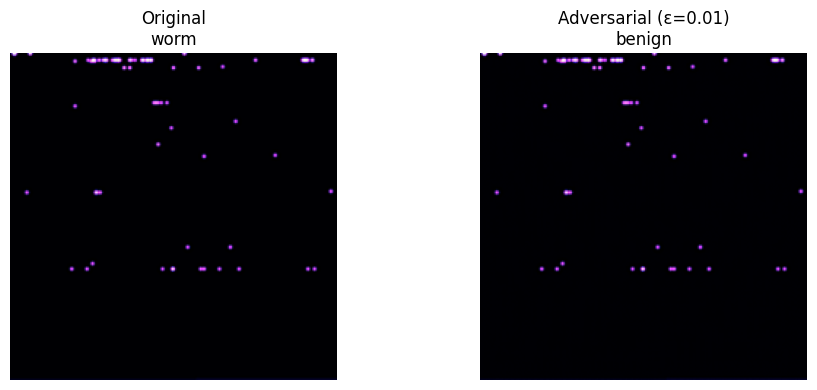

In [22]:
# 8) Évaluer sur la première batch
# =========================
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Prédictions sur images propres
with torch.no_grad():
    clean_pred = model(images).argmax(dim=1)

# Génération d'images adversariales
x_adv = fgsm_attack(model, images, labels, EPSILON)

# Prédictions sur images adversariales
with torch.no_grad():
    adv_pred = model(x_adv).argmax(dim=1)

# Calcul du succès de l'attaque
originally_correct = (clean_pred == labels)
flipped = (adv_pred != labels) & originally_correct
success = flipped.sum().item() / max(int(originally_correct.sum().item()), 1)
print(f"\nFGSM flips (première batch avec epsilon={EPSILON}): {success:.2%}")

# =========================
# 9) Test sur une seule image avec visualisation
# =========================
# Pick an image from the test dataset
idx = 2200  # Change this if dataset has fewer than 100 images
if idx >= len(test_dataset):
    idx = 0  # Fallback to first image

image, label = test_dataset[idx]
image = image.unsqueeze(0).to(device)
label = torch.tensor([label]).to(device)

# Predict original
with torch.no_grad():
    pred = model(image).argmax(dim=1)

print(f"\n=== Test sur image individuelle (index {idx}) ===")
print(f"Classe réelle : {test_dataset.classes[label.item()]}")
print(f"Classe prédite avant FGSM : {test_dataset.classes[pred.item()]}")

# Generate FGSM adversarial image with higher epsilon for visibility
epsilon_single = 0.01 # Higher epsilon for single image demo
x_adv = fgsm_attack(model, image, label, epsilon=epsilon_single)

# Predict on adversarial
with torch.no_grad():
    adv_pred = model(x_adv).argmax(dim=1)

print(f"Classe prédite après FGSM (epsilon={epsilon_single}) : {test_dataset.classes[adv_pred.item()]}")

# Display images
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
imshow(image, title=f"Original\n{test_dataset.classes[pred.item()]}")
plt.subplot(1, 2, 2)
imshow(x_adv, title=f"Adversarial (ε={epsilon_single})\n{test_dataset.classes[adv_pred.item()]}")
plt.tight_layout()
plt.show()
#for epsilon=0.01 the predicted class after fgsm is always benign
# " "        0.5            "    "               "         worm

In [23]:
def evaluate_accuracy(model, dataloader, device, epsilon=0.2, use_fgsm=False):
    model.eval()
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial examples if needed
        if use_fgsm:
            images = fgsm_attack(
                model, images, labels, epsilon=epsilon, targeted=False
            )

        with torch.no_grad():
            outputs = model(images)
            preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy


In [24]:


# Accuracy on clean images
clean_acc = evaluate_accuracy(
    model,
    test_loader,
    device,
    use_fgsm=False
)

# Accuracy on adversarial images
adv_acc = evaluate_accuracy(
    model,
    test_loader,
    device,
    epsilon=0.2,
    use_fgsm=True
)

print(f"Accuracy BEFORE FGSM : {clean_acc:.2f}%")
print(f"Accuracy AFTER FGSM  : {adv_acc:.2f}%")


TypeError: fgsm_attack() got an unexpected keyword argument 'targeted'

In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T

# =========================
# 1) Paramètres
# =========================
epsilon = 0.1
num_images = 4  # combien d'images afficher
images_batch, labels_batch = next(iter(test_loader))
images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

# =========================
# 2) Fonction pour afficher une image (denormalisée)
# =========================
def show_image(tensor_img):
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(tensor_img.squeeze()).clamp(0,1)
    img = img.permute(1,2,0).cpu().numpy()
    plt.imshow(img)
    plt.axis('off')

# =========================
# 3) Générer les adversarials
# =========================
x_adv_batch = fgsm_attack(model, images_batch[:num_images], labels_batch[:num_images], epsilon)

# =========================
# 4) Prédictions
# =========================
with torch.no_grad():
    clean_preds = model(images_batch[:num_images]).argmax(dim=1)
    adv_preds = model(x_adv_batch).argmax(dim=1)

# =========================
# 5) Affichage côte à côte
# =========================
plt.figure(figsize=(12,6))
for i in range(num_images):
    # image originale
    plt.subplot(2, num_images, i+1)
    show_image(images_batch[i])
    plt.title(f"Vrai: {test_dataset.classes[labels_batch[i]]}\nPred: {test_dataset.classes[clean_preds[i]]}")

    # image adversariale
    plt.subplot(2, num_images, i+1+num_images)
    show_image(x_adv_batch[i])
    plt.title(f"Pred FGSM: {test_dataset.classes[adv_preds[i]]}")

plt.tight_layout()
plt.show()
